In [1]:
# Pour la manipulation de tableaux
import numpy as np

# Imports nécessaires pour construire un modèle CNN avec l'API fonctionnelle de Keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications.inception_v3 import preprocess_input
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import tensorflow as tf

# Pour encoder les labels
from tensorflow.keras.utils import to_categorical 

# Pour évaluer les performances 
from sklearn import metrics

# Pour visualiser les performances
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
import keras



I0000 00:00:1785658393.993141    5591 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785658394.177465    5591 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785658395.480932    5591 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
val_ds = image_dataset_from_directory(
    directory="../../../COVID-19_Radiography_Dataset_split/validation/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='rgb'
)


# Pour avoir le nom des classes 
class_names_val = val_ds.class_names


# %%
test_ds = image_dataset_from_directory(
    directory="../../../COVID-19_Radiography_Dataset_split/test/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='rgb'
)

# Pour avoir le nom des classes 
class_names_test = test_ds.class_names


val_ds_pred = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds_pred = test_ds.map(lambda x, y: (preprocess_input(x), y))



Found 2083 files belonging to 4 classes.
Found 2084 files belonging to 4 classes.


W0000 00:00:1785658397.489033    5591 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
@keras.saving.register_keras_serializable()
class SparseF1Score(tf.keras.metrics.F1Score):
    """F1Score de Keras adaptée aux labels sparses (entiers) plutôt que one-hot."""
    def __init__(self, num_classes=4, **kwargs):
        super().__init__(**kwargs)
        self.num_classes_ = num_classes

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32), depth=self.num_classes_)
        return super().update_state(y_true, y_pred, sample_weight)
    


In [4]:
#model_loaded = load_model('inceptionv3_head.keras')
model_loaded = load_model('inceptionv3_finetuned.keras')
model_loaded.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 299, 299,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ Input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 44,820,910 (170.98 MB)

 Trainable params: 11,377,668 (43.40 MB)

 Non-trainable params: 10,687,904 (40.77 MB)

 Optimizer params: 22,755,338 (86.80 MB)

In [5]:

# jeu de test
test_pred = model_loaded.predict(test_ds_pred)
test_pred_class = test_pred.argmax(axis=1)
y_true_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)

# jeu de validation
val_pred = model_loaded.predict(val_ds_pred)
val_pred_class = val_pred.argmax(axis=1)
y_true_val_class = np.concatenate([labels for images,labels in val_ds] ,axis=0)

# sauvegarde sous la forme npy 
model_name = "inceptionv3"
y_true_test_model_name="y_true_test_"+model_name+".npy"
y_prob_test__model_name="y_prob_test_"+model_name+".npy"
np.save(y_true_test_model_name, y_true_test_class)  # changer le nom selon le modèle
np.save(y_prob_test__model_name, test_pred)

I0000 00:00:1785658400.704354    6130 service.cc:153] XLA service 0x7f6c84076820 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785658400.704410    6130 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1785658400.755865    6130 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785658401.543866    6130 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/66 ━━━━━━━━━━━━━━━━━━━━ 58s 843ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 50s 754ms/step


In [6]:
def evaluer(model, y, y_pred, titre):
    """Affiche accuracy, classification_report et matrice de confusion."""
   
    acc = accuracy_score(y, y_pred)

    print(f"===== {titre} =====")
    print(f"Accuracy : {acc:.4f}\n")
    print(classification_report(y, y_pred, zero_division=0))

    cm = confusion_matrix(y, y_pred,normalize='true')
    class_names = test_ds.class_names
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = class_names)
    cm_display.plot()
    plt.tight_layout()
    plt.show()
    return acc


===== inceptionv3 - Validation =====
Accuracy : 0.8833

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       338
           1       0.85      0.86      0.86       598
           2       0.91      0.91      0.91      1013
           3       0.99      0.99      0.99       134

    accuracy                           0.88      2083
   macro avg       0.89      0.89      0.89      2083
weighted avg       0.88      0.88      0.88      2083



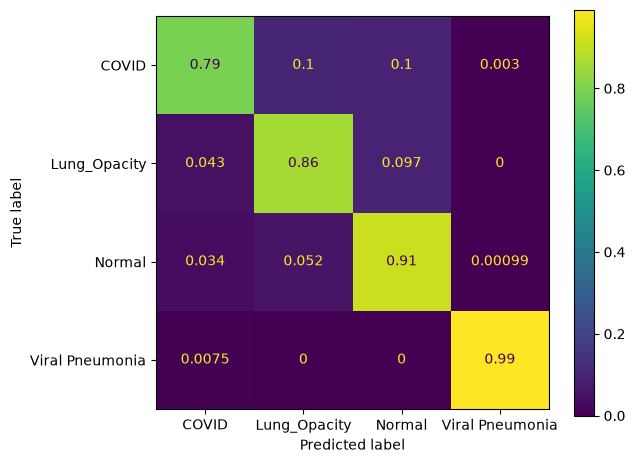

===== inceptionv3 - Test =====
Accuracy : 0.8762

              precision    recall  f1-score   support

           0       0.78      0.79      0.79       337
           1       0.85      0.83      0.84       599
           2       0.91      0.92      0.91      1014
           3       0.99      0.99      0.99       134

    accuracy                           0.88      2084
   macro avg       0.88      0.88      0.88      2084
weighted avg       0.88      0.88      0.88      2084



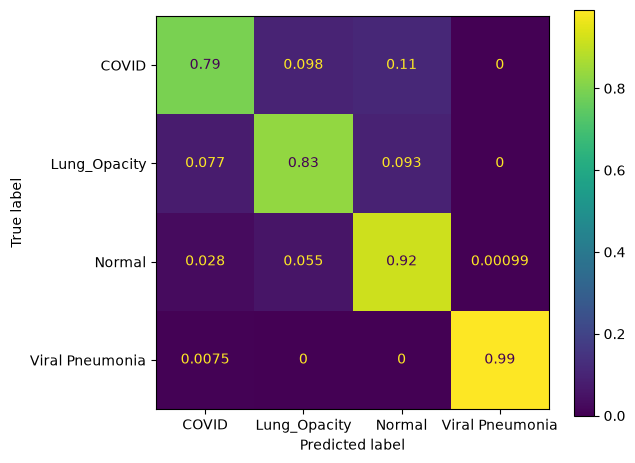

In [7]:
acc_val  = evaluer(model_loaded, y_true_val_class, val_pred_class,  model_name + " - Validation")
acc_test = evaluer(model_loaded, y_true_test_class, test_pred_class,  model_name + " - Test")